<details>
<summary>
<span style="color:#1f77b4; font-size:20px; font-weight:bold;">
📌 Amazon Review Intelligence — Project Overview
</span>
</summary>

# Amazon Review Intelligence

### NLP analysis of Amazon Home & Kitchen reviews: text sentiment, topics and business insights

---

# Goal

A seller on Amazon has hundreds of thousands of reviews. The star rating shows *how* satisfied a customer is, but not *what exactly* went wrong. This project turns raw review text into analytics: it detects sentiment, extracts topics, finds cases where the stars contradict the text, and presents everything in an interactive dashboard.

---

# Project structure

The analysis is split into three notebooks, run in order:

- **01_data_eda** — data preparation and exploratory analysis
- **02_sentiment_models** — sentiment models
- **03_topics_insights** — topics and business insights

Plus a Streamlit dashboard (`app.py`) with live sentiment prediction.

---

# Stages

## Notebook 01

**1.1 Data Ingestion.** The large JSONL file is read in chunks; a uniform random sample of 500k reviews (2019+) is collected via reservoir sampling and cached in parquet.

**1.2 Data Cleaning.** Remove duplicates (full rows and identical texts) and reviews shorter than 20 characters.

**1.3 NLP Preprocessing.** Lowercase, expand contractions (can't → can not), strip HTML, links and punctuation, remove stop words (keeping "not" — it changes sentiment).

**1.4 EDA.** Rating distribution and class imbalance; star ratings converted into sentiment labels (1–2 negative, 3 neutral, 4–5 positive); frequent words and bigrams per class; activity over time.

## Notebook 02

**2.1 Sentiment Analysis.** TF-IDF features; three baseline models — Logistic Regression, LinearSVC (calibrated), LightGBM; comparison by accuracy and macro-F1, error analysis.

**2.2 Deployment.** A single pipeline "raw text → cleaning → model → sentiment", saved to disk and verified on examples.

**2.3 LinearSVC Tuning.** Hyperparameter search (RandomizedSearchCV) by macro-F1: 0.657 → 0.717.

**2.4 DistilBERT.** A transformer fine-tuned on raw text (GPU). Best model of the project: macro-F1 0.744 — it powers the dashboard.

## Notebook 03

**3.1 Topic Modeling (LDA).** 12 topics with business-friendly names; topic frequencies and the dominant topic of each review.

**3.2 Mismatch Analysis.** Reviews where the predicted sentiment contradicts the star rating (e.g. 1★ with positive text), filtered by model confidence.

**3.3 Insight Fusion.** Most negative topics (pain points), helpful votes and verified purchases per topic, sentiment trends by month.

**3.4 Dashboard.** Summary visualizations: topic × sentiment heatmap, most negative topics, trends.

**3.5 BERTopic vs LDA.** Topics built a second way — on sentence embeddings; why LDA remains the dashboard model.

</details>

<details>
<summary>
<span style="color:#1f77b4; font-size:20px; font-weight:bold;">
📌 Amazon Review Intelligence — Описание проекта
</span>
</summary>

# Amazon Review Intelligence

### Анализ отзывов Amazon (Home & Kitchen): тональность текста, темы и бизнес-инсайты

---

# Цель

У продавца на Amazon сотни тысяч отзывов. Звёздный рейтинг показывает, *насколько* доволен покупатель, но не объясняет, *что именно* не так. Проект превращает сырой текст отзывов в аналитику: определяет тональность, выделяет темы, находит противоречия «звёзды против текста» и показывает всё это в интерактивном дашборде.

---

# Состав проекта

Анализ разбит на три ноутбука, они выполняются по порядку:

- **01_data_eda** — подготовка данных и разведочный анализ
- **02_sentiment_models** — модели тональности
- **03_topics_insights** — темы и бизнес-инсайты

Отдельно — Streamlit-дашборд (`app.py`) с предсказанием тональности в реальном времени.

---

# Этапы

## Ноутбук 01

**1.1 Data Ingestion.** Большой JSONL-файл читается частями; случайная равномерная выборка 500 тысяч отзывов (с 2019 года) собирается методом reservoir sampling и кэшируется в parquet.

**1.2 Data Cleaning.** Удаляем дубликаты (полные и по тексту) и отзывы короче 20 символов.

**1.3 NLP Preprocessing.** Нижний регистр, раскрытие сокращений (can't → can not), удаление HTML, ссылок и пунктуации, удаление стоп-слов (слово «not» оставляем — оно меняет тональность).

**1.4 EDA.** Распределение рейтингов и дисбаланс классов; перевод звёзд в классы тональности (1–2 — negative, 3 — neutral, 4–5 — positive); частые слова и биграммы по классам; активность по времени.

## Ноутбук 02

**2.1 Sentiment Analysis.** Признаки TF-IDF; три базовые модели — Logistic Regression, LinearSVC (с калибровкой), LightGBM; сравнение по accuracy и macro-F1, разбор ошибок.

**2.2 Deployment.** Единый пайплайн «сырой текст → очистка → модель → тональность», сохранение на диск и проверка на примерах.

**2.3 Тюнинг LinearSVC.** Подбор гиперпараметров (RandomizedSearchCV) по macro-F1: 0.657 → 0.717.

**2.4 DistilBERT.** Дообучение трансформера на сыром тексте (GPU). Лучшая модель проекта: macro-F1 0.744 — именно она работает в дашборде.

## Ноутбук 03

**3.1 Topic Modeling (LDA).** 12 тем с понятными бизнес-названиями; частоты тем и доминирующая тема каждого отзыва.

**3.2 Mismatch Analysis.** Отзывы, где предсказанная тональность противоречит рейтингу (например, 1★ с позитивным текстом), с фильтром по уверенности модели.

**3.3 Insight Fusion.** Самые негативные темы (pain points), голоса полезности и подтверждённые покупки по темам, тренды тональности по месяцам.

**3.4 Dashboard.** Сводные визуализации: heatmap «тема × тональность», самые негативные темы, тренды.

**3.5 BERTopic vs LDA.** Темы вторым способом — на смысловых векторах предложений; почему в дашборде остался LDA.

</details>

## Notebook 01 — Data & Exploratory Analysis

What happens in this notebook:
- load reviews from a large JSONL file and collect a random sample of 500k rows (2019+);
- remove duplicates and overly short reviews;
- clean the text: HTML, links, contractions, punctuation, stop words;
- explore the data: rating distribution, frequent words, activity over time;
- convert star ratings into sentiment classes (negative / neutral / positive) and study the text within each class.

**Output:** `data/reviews_clean.parquet` — the prepared dataset that notebooks [02](02_sentiment_models.ipynb) and [03](03_topics_insights.ipynb) start from.

---

## Ноутбук 01 — Данные и разведочный анализ

Что происходит в этом ноутбуке:
- загружаем отзывы из большого JSONL-файла и собираем случайную выборку 500 тысяч строк (с 2019 года);
- убираем дубликаты и слишком короткие отзывы;
- чистим текст: HTML, ссылки, сокращения, пунктуация, стоп-слова;
- смотрим на данные: распределение рейтингов, частые слова, активность по времени;
- переводим звёздные рейтинги в классы тональности (negative / neutral / positive) и изучаем текст внутри каждого класса.

**Выход:** `data/reviews_clean.parquet` — подготовленный датасет, с которого начинаются ноутбуки [02](02_sentiment_models.ipynb) и [03](03_topics_insights.ipynb).

In [1]:
# All paths in the project are relative to the repo root (data/, models/):
# the notebook lives in notebooks/, so we move one level up
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

# Imports and environment setup
import re

from html import unescape
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

# Pandas display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Matplotlib plot style
plt.style.use("ggplot")

## 1.1 Data Ingestion

We read the reviews file in chunks (it does not fit in memory), keep reviews from 2019 onward and build a reproducible random sample of 500k rows. The result is cached in parquet, so repeated runs start instantly.

Читаем файл с отзывами частями (целиком он не помещается в память), оставляем отзывы с 2019 года и собираем воспроизводимую случайную выборку 500 тысяч строк. Результат кэшируется в parquet, поэтому повторные запуски начинаются мгновенно.

In [2]:
# Path to the local JSONL file with reviews
DATA_PATH = "data/Home_and_Kitchen.jsonl"
PARQUET_PATH = "data/reviews_processed.parquet"

if os.path.exists(PARQUET_PATH):
    reviews = pd.read_parquet(PARQUET_PATH)
    parquet_loaded = True
    print(f"Loaded from parquet: {reviews.shape}")
else:
    parquet_loaded = False
    print("Parquet not found — running full pipeline...")

Loaded from parquet: (500000, 10)


In [3]:
if not parquet_loaded:

    # Read the whole file in chunks and build a uniform random sample using
    # reservoir sampling (the "smallest random key" method).
    #
    # Previously loading stopped after the first ~500k rows from the START of the
    # file, which biased the sample (time/category bias if the file is sorted).
    # Now every eligible row (year >= 2019) has an equal chance to enter the
    # sample, and we keep at most SAMPLE_SIZE rows in memory.
    # The cost is one full pass over the file (the result is cached in parquet).

    SAMPLE_SIZE = 500_000
    MIN_YEAR = 2019

    rng = np.random.default_rng(42)

    reservoir = None   # DataFrame with the best (smallest) random keys
    seen = 0           # total number of eligible rows seen

    chunks = pd.read_json(
        DATA_PATH,
        lines=True,
        chunksize=100_000
    )

    for chunk in chunks:

        # Convert timestamp from milliseconds to datetime and filter by year
        chunk["timestamp"] = pd.to_datetime(chunk["timestamp"], unit="ms")
        chunk = chunk[chunk["timestamp"].dt.year >= MIN_YEAR].copy()

        if chunk.empty:
            continue

        # Assign a random key to each row; globally keep the SAMPLE_SIZE rows
        # with the smallest keys — equivalent to uniform sampling without replacement.
        chunk["_key"] = rng.random(len(chunk))
        seen += len(chunk)

        reservoir = chunk if reservoir is None else pd.concat(
            [reservoir, chunk],
            ignore_index=True
        )

        if len(reservoir) > SAMPLE_SIZE:
            reservoir = reservoir.nsmallest(SAMPLE_SIZE, "_key")

        print(f"Seen eligible rows: {seen} | reservoir: {len(reservoir)}")

    # Finalize the sample
    reviews = (
        reservoir
        .drop(columns="_key")
        .reset_index(drop=True)
    )

    print(reviews.shape)

    # Save the sample to parquet for fast loading next time
    reviews.to_parquet(PARQUET_PATH, index=False)
    print(f"Saved to parquet: {reviews.shape}")

In [4]:
# Look at the available column names
print(reviews.columns)

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='str')


In [5]:
# Quick look at the first rows
reviews.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,A must have in your kitchen,These are the best spatulas ever! No more handle falling out.,[],B07C73RZJ5,B09ZNPBBSC,AEULMCSWDA2WWWTSO7DL4MR5DYEQ,2019-06-26 13:05:49.656,0,True
1,4,A very pretty Christmas tablecloth,Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,[],B0B5LTR4ZM,B0B5LTR4ZM,AHEJ5LC7BSEADCIZQQQPZPVWOLCA,2022-11-20 19:27:06.340,0,True
2,5,A beautiful washable outer shower curtain,"When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion is amazing and perfect in the middle of a ...",[],B08HMVBQ51,B08HMVBQ51,AFJ74T4L5ZMC7PCNN4C567JNFWWA,2021-01-26 01:29:41.556,1,False
3,5,Perfect!,This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,[],B076J79XVJ,B076J79XVJ,AFOYWNZOJ2OF5WEQ5UFUGDWTLYLA,2019-06-19 14:22:12.796,0,True
4,2,Temperature inaccurate and timer only 30 minutes,"Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information there. I am returning it.",[],B06WGNC8Q4,B0BG18FLM5,AFHMGLTJWWAYSNAJYVX3U3XMLKKQ,2021-05-25 16:52:44.217,0,True


In [6]:
# Check the number of rows and columns
print(reviews.shape)

(500000, 10)


In [7]:
# Check data types and missing values per column
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             500000 non-null  int64         
 1   title              500000 non-null  str           
 2   text               500000 non-null  str           
 3   images             500000 non-null  object        
 4   asin               500000 non-null  str           
 5   parent_asin        500000 non-null  str           
 6   user_id            500000 non-null  str           
 7   timestamp          500000 non-null  datetime64[ns]
 8   helpful_vote       500000 non-null  int64         
 9   verified_purchase  500000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(1), str(5)
memory usage: 180.7+ MB


## 1.2 Data Cleaning

We keep the columns we need, check missing values and duplicates, then remove repeated and overly short reviews.

Оставляем нужные колонки, проверяем пропуски и дубликаты, затем удаляем повторяющиеся и слишком короткие отзывы.

In [8]:
# Keep only the columns needed for further analysis
reviews = reviews[
    [
        "rating",
        "title",
        "text",
        "asin",
        "user_id",
        "timestamp",
        "helpful_vote",
        "verified_purchase"
    ]
]

In [9]:
# Count missing values per column
reviews.isnull().sum()

rating               0
title                0
text                 0
asin                 0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [10]:
# Count fully duplicated rows
reviews.duplicated().sum()

np.int64(610)

In [11]:
# Count duplicates by review text specifically
reviews["text"].duplicated().sum()

np.int64(25826)

In [12]:
# Drop fully duplicated rows
reviews = reviews.drop_duplicates()

# Drop reviews with identical text
reviews = reviews.drop_duplicates(subset="text")

# Reset the index after removing duplicates
reviews = reviews.reset_index(drop=True)

print(reviews.shape)

(474174, 8)


In [13]:
# Add text length to find overly short reviews
reviews["text_length"] = reviews["text"].str.len()
reviews["text_length"].describe()

count    474174.000000
mean        246.525721
std         318.494167
min           1.000000
25%          70.000000
50%         150.000000
75%         304.000000
max       16765.000000
Name: text_length, dtype: float64

In [14]:
# the longest review
print(reviews.loc[reviews["text"].str.len().idxmax(), "text"])

[[VIDEOID:ebcb5c66d7e130236fff252f142f6657]] 061622 EDIT:<br />2-STARS because breville needs to do a heck of a lot better for the pricE (costing 10-times more than other burners).  For the price: No leveling feet..  Flaky recognizing demeyere (top of the line pan specifically engineered for induction cooking).  Like all the other induction burners I know of, the heating/induction part is a ring that causes a corresponding ring shaped hot-spot in all pans used (since induction heats the pan itself the ring shape gets heated)..  I don’t know why everyone believes induction is good for even heat, because it actually makes it worse because it heats the pan itself in a ring shape (so the ring shaped hot spot ends up a hotspot).<br /><br />[[EDIT: the boiling ring in the video happened with cast iron STAUB, and top of the line thick aluminum demeyere Atlantis gets the boiling ring too..  The demeyere Atlantis, which is the thickest aluminum I’ve ever seen (and it still boils in a ring)..  T

In [15]:
# Look at examples of short reviews before dropping them
reviews[reviews["text_length"] < 20][
    ["rating", "text"]
].head(10)

,rating,text
5,5,fits great
13,5,Love all the items
20,5,Color
24,5,It’s good
27,5,Very nice
47,5,Great hangers!
60,5,Very satisfied.
62,4,Good product
70,5,Very cute
75,5,Perfect


In [16]:
# Drop overly short reviews as uninformative
reviews = reviews[
    reviews["text_length"] >= 20
]

# Drop the helper column, no longer needed
reviews = reviews.drop(columns=["text_length"])

## 1.3 NLP Preprocessing

We prepare the text for modeling: convert to lowercase, expand contractions (can't → can not), remove HTML, links and punctuation, and merge `title + text` into a single field — titles often carry a strong sentiment signal ("Terrible!", "Love it"). A separate column without stop words is added for word-frequency analysis; the word "not" is kept because it flips the meaning.

Готовим текст для моделей: приводим к нижнему регистру, раскрываем сокращения (can't → can not), убираем HTML, ссылки и пунктуацию и объединяем `title + text` в одно поле — заголовки часто несут сильный сигнал тональности («Terrible!», «Love it»). Отдельно добавляем колонку без стоп-слов для частотного анализа; слово «not» сохраняем, потому что оно меняет смысл фразы.

In [17]:
# Clean the review text for downstream NLP
def clean_review_text(text):

    if pd.isna(text):
        return ""

    text = unescape(str(text))
    text = text.lower()

    # contractions
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"\bwon't\b", "will not", text)

    text = re.sub(r"\bit's\b", "it is", text)
    text = re.sub(r"\bthat's\b", "that is", text)
    text = re.sub(r"\bthere's\b", "there is", text)
    text = re.sub(r"\bhere's\b", "here is", text)
    text = re.sub(r"\bwhat's\b", "what is", text)

    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'re\b", " are", text)
    text = re.sub(r"'d\b", " would", text)
    text = re.sub(r"'ll\b", " will", text)
    text = re.sub(r"'ve\b", " have", text)
    text = re.sub(r"'m\b", " am", text)

    # remove possessive 's
    text = re.sub(r"'s\b", "", text)

    # remove urls/html
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)

    # remove punctuation
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Merge title and body: the title often carries a strong sentiment signal
# ("Terrible!", "Love it"), so both fields form a single model input.
reviews["full_text"] = (
    reviews["title"].fillna("").astype(str)
    + ". "
    + reviews["text"].fillna("").astype(str)
)

reviews["clean_text"] = reviews["full_text"].apply(clean_review_text)

reviews[["title", "text", "clean_text"]].head()

,title,text,clean_text
0,A must have in your kitchen,These are the best spatulas ever! No more handle falling out.,a must have in your kitchen these are the best spatulas ever no more handle falling out
1,A very pretty Christmas tablecloth,Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,a very pretty christmas tablecloth something new for the christmas season finally bought a new christmas tablecloth it is very pretty
2,A beautiful washable outer shower curtain,"When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion is amazing and perfect in the middle of a ...",a beautiful washable outer shower curtain when i hung this up it was like redecorating my whole small bathroom the image is a tropical beach seen through white shutter style doors the illusion is ...
3,Perfect!,This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,perfect this is perfect for a small sink i purchased for our camper i am very happy with it
4,Temperature inaccurate and timer only 30 minutes,"Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information there. I am returning it.",temperature inaccurate and timer only 30 minutes temperature lower than it should be and in paragraph about this item no mention timer was only 30 minutes they should place that information there ...


In [18]:
# Remove stop words and short junk tokens
stop_words = set(ENGLISH_STOP_WORDS) - {"not"}

extra_stop_words = {
    "t", "s", "m", "don", "ve", "ll", "re", "d"
}

def remove_stopwords(text):
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words
        and word not in extra_stop_words
        and len(word) > 1
    ]
    return " ".join(words)

reviews["clean_text_no_stopwords"] = reviews["clean_text"].apply(remove_stopwords)

reviews[["clean_text", "clean_text_no_stopwords"]].head()

,clean_text,clean_text_no_stopwords
0,a must have in your kitchen these are the best spatulas ever no more handle falling out,kitchen best spatulas handle falling
1,a very pretty christmas tablecloth something new for the christmas season finally bought a new christmas tablecloth it is very pretty,pretty christmas tablecloth new christmas season finally bought new christmas tablecloth pretty
2,a beautiful washable outer shower curtain when i hung this up it was like redecorating my whole small bathroom the image is a tropical beach seen through white shutter style doors the illusion is ...,beautiful washable outer shower curtain hung like redecorating small bathroom image tropical beach seen white shutter style doors illusion amazing perfect middle snowy colorado winter curtain grom...
3,perfect this is perfect for a small sink i purchased for our camper i am very happy with it,perfect perfect small sink purchased camper happy
4,temperature inaccurate and timer only 30 minutes temperature lower than it should be and in paragraph about this item no mention timer was only 30 minutes they should place that information there ...,temperature inaccurate timer 30 minutes temperature lower paragraph item mention timer 30 minutes place information returning


In [19]:
reviews.head()

,rating,title,text,asin,user_id,timestamp,helpful_vote,verified_purchase,full_text,clean_text,clean_text_no_stopwords
0,5,A must have in your kitchen,These are the best spatulas ever! No more handle falling out.,B07C73RZJ5,AEULMCSWDA2WWWTSO7DL4MR5DYEQ,2019-06-26 13:05:49.656,0,True,A must have in your kitchen. These are the best spatulas ever! No more handle falling out.,a must have in your kitchen these are the best spatulas ever no more handle falling out,kitchen best spatulas handle falling
1,4,A very pretty Christmas tablecloth,Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,B0B5LTR4ZM,AHEJ5LC7BSEADCIZQQQPZPVWOLCA,2022-11-20 19:27:06.340,0,True,A very pretty Christmas tablecloth. Something new for the Christmas season finally bought a new Christmas tablecloth it's very pretty,a very pretty christmas tablecloth something new for the christmas season finally bought a new christmas tablecloth it is very pretty,pretty christmas tablecloth new christmas season finally bought new christmas tablecloth pretty
2,5,A beautiful washable outer shower curtain,"When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion is amazing and perfect in the middle of a ...",B08HMVBQ51,AFJ74T4L5ZMC7PCNN4C567JNFWWA,2021-01-26 01:29:41.556,1,False,"A beautiful washable outer shower curtain. When I hung this up, it was like redecorating my whole small bathroom. The image is a tropical beach seen through white shutter-style doors. The illusion...",a beautiful washable outer shower curtain when i hung this up it was like redecorating my whole small bathroom the image is a tropical beach seen through white shutter style doors the illusion is ...,beautiful washable outer shower curtain hung like redecorating small bathroom image tropical beach seen white shutter style doors illusion amazing perfect middle snowy colorado winter curtain grom...
3,5,Perfect!,This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,B076J79XVJ,AFOYWNZOJ2OF5WEQ5UFUGDWTLYLA,2019-06-19 14:22:12.796,0,True,Perfect!. This is perfect for a small sink. I purchased for our camper. I'm very happy with it.,perfect this is perfect for a small sink i purchased for our camper i am very happy with it,perfect perfect small sink purchased camper happy
4,2,Temperature inaccurate and timer only 30 minutes,"Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information there. I am returning it.",B06WGNC8Q4,AFHMGLTJWWAYSNAJYVX3U3XMLKKQ,2021-05-25 16:52:44.217,0,True,"Temperature inaccurate and timer only 30 minutes. Temperature lower than it should be and in paragraph ""About this item"" no mention timer was only 30 minutes. They should place that information th...",temperature inaccurate and timer only 30 minutes temperature lower than it should be and in paragraph about this item no mention timer was only 30 minutes they should place that information there ...,temperature inaccurate timer 30 minutes temperature lower paragraph item mention timer 30 minutes place information returning


## 1.4 Exploratory Data Analysis (EDA)

We look at rating distribution, class imbalance, verified purchases and helpful votes.

Смотрим на распределение рейтингов, дисбаланс классов, подтверждённые покупки (verified purchase) и голоса полезности (helpful votes).

In [20]:
# Count reviews per rating
reviews["rating"].value_counts()

rating
5    318675
4     57838
3     32526
1     32053
2     19605
Name: count, dtype: int64

In [21]:
# Share of each rating in percent
reviews["rating"].value_counts(normalize=True) * 100

rating
5    69.172363
4    12.554456
3     7.060172
1     6.957501
2     4.255509
Name: proportion, dtype: float64

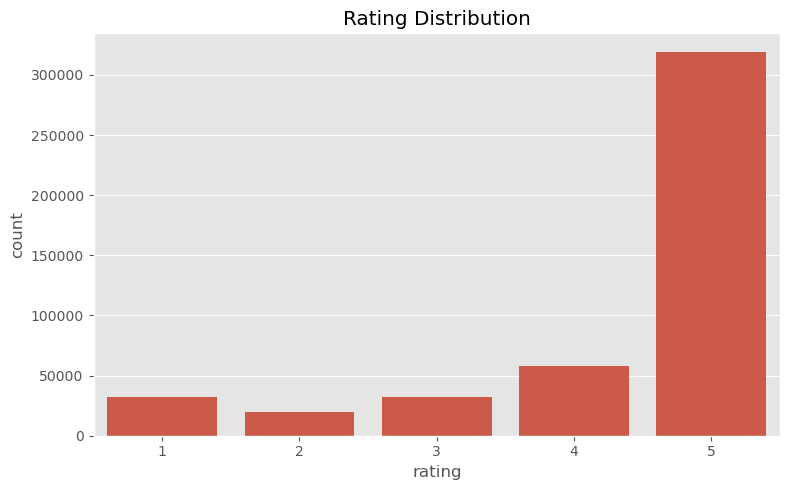

In [22]:
# Plot the rating distribution to assess class imbalance
plt.figure(figsize=(8,5))

sns.countplot(
    x=reviews["rating"]
)

plt.title("Rating Distribution")
plt.tight_layout()
plt.show()

The dataset is heavily imbalanced: most reviews are positive (4–5 stars ≈ 82%), while neutral and negative classes are much smaller. This is typical for real-world review data and must be taken into account when training models.

В датасете сильный дисбаланс классов: большинство отзывов положительные (4–5 звёзд ≈ 82%), а классов neutral и negative значительно меньше. Это типично для реальных данных с отзывами, и при обучении моделей дисбаланс нужно учитывать.

In [23]:
# Check how many reviews come from verified purchases
reviews["verified_purchase"].value_counts()

verified_purchase
True     382661
False     78036
Name: count, dtype: int64

In [24]:
# Analyze the distribution of helpful votes
reviews["helpful_vote"].describe()

count    460697.000000
mean          0.917438
std          11.256480
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        3429.000000
Name: helpful_vote, dtype: float64

### Sentiment labels

We convert star ratings into three target classes: 1–2 → negative, 3 → neutral, 4–5 → positive. This gives free labels for the whole dataset (weak supervision): no manual annotation, at the cost of some noise — a 3-star review is not always truly neutral.

Переводим звёздные рейтинги в три целевых класса: 1–2 → negative, 3 → neutral, 4–5 → positive. Так мы получаем бесплатную разметку всего датасета (weak supervision): без ручной аннотации, но ценой шума — отзыв с тремя звёздами не всегда действительно нейтральный.

In [25]:
# Check the valid rating values
reviews["rating"].value_counts().sort_index()

# Convert the rating into the target sentiment label
sentiment_conditions = [
    reviews["rating"].isin([1, 2]),
    reviews["rating"].eq(3),
    reviews["rating"].isin([4, 5])
]

sentiment_labels = [
    "negative",
    "neutral",
    "positive"
]

reviews["sentiment_label"] = np.select(
    sentiment_conditions,
    sentiment_labels,
    default=None
)

# Check for unknown sentiment classes
print(reviews["sentiment_label"].isna().sum())
assert reviews["sentiment_label"].isna().sum() == 0

0


As shown above, the classes are imbalanced and most reviews are positive. Therefore, when evaluating models we will look not only at accuracy but also at precision, recall and F1-score for each class.

Как показано выше, классы несбалансированы и большинство отзывов положительные. Поэтому при оценке моделей будем смотреть не только на accuracy, но и на precision, recall и F1-score по каждому классу.

### Text EDA by sentiment class

We analyze the length of cleaned text, example reviews per class, and the most frequent words and bigrams.

Анализируем длину очищенного текста, примеры отзывов по классам тональности, самые частые слова и биграммы.

In [26]:
# Add the length of the cleaned text
reviews["clean_text_length"] = reviews["clean_text"].str.len()

reviews["clean_text_length"].describe()

count    460697.000000
mean        266.952869
std         310.172273
min           7.000000
25%          92.000000
50%         173.000000
75%         326.000000
max       15542.000000
Name: clean_text_length, dtype: float64

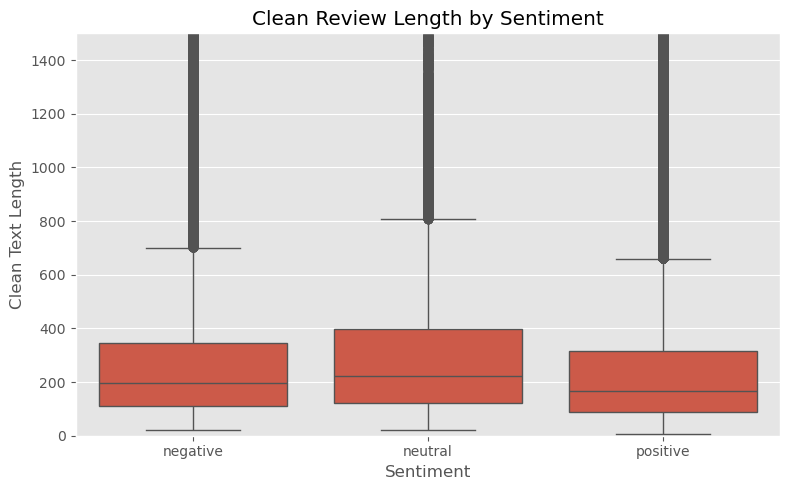

In [27]:
# Compare review length across sentiment classes
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=reviews,
    x="sentiment_label",
    y="clean_text_length",
    order=["negative", "neutral", "positive"]
)

plt.title("Clean Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Clean Text Length")
plt.ylim(0, 1500)
plt.tight_layout()
plt.show()

In [28]:
# Look at random review examples from each class
reviews[
    ["rating", "sentiment_label", "text", "clean_text"]
].groupby("sentiment_label", group_keys=False).apply(
    lambda x: x.sample(3, random_state=42)
)

,rating,text,clean_text
210760,1,These plate stands open all the way flat which is not supportive for valuable plates. They tip easily. Very disappointed and do not recommend.,cheap these plate stands open all the way flat which is not supportive for valuable plates they tip easily very disappointed and do not recommend
354669,2,"This was way thinner than expected, allowed in way too much light and heat. Returned for thicker.",blocks very little light but is a nice looking curtain if you just want it for show this was way thinner than expected allowed in way too much light and heat returned for thicker
22952,1,Cheap quality small. One of the photos made it look like it was bigger than it is I could go into a crafts store and pale lot less for this piece of junk.,this is very cheap quality and small you could make it cheaper by yourself cheap quality small one of the photos made it look like it was bigger than it is i could go into a crafts store and pale ...
445692,3,"This shelf isn't as nice as I hoping it would be. Most of it is actually particle board instead of real wood. The dream catchers are very cheaply made, I even had to reattach some of the feathers ...",not as good as i was hoping this shelf is not as nice as i hoping it would be most of it is actually particle board instead of real wood the dream catchers are very cheaply made i even had to reat...
4841,3,"This is a different idea to steam a small amount<br />Of food!<br /><br /> You have to put this steamer top over a pan with water to get the steam<br />To your food.<br />I understand, I use a reg...",does not hold 2 pieces of salmon very small no lid to steam with this is a different idea to steam a small amount of food you have to put this steamer top over a pan with water to get the steam to...
234943,3,"Not Silicone, though description says they are. I wouldn't wash these in dishwasher. I ordered several batches of these bags in different brands and none of them hold up well in the dishwasher. Th...",dishwasher safe not silicone not silicone though description says they are i would not wash these in dishwasher i ordered several batches of these bags in different brands and none of them hold up...
252853,5,Machine wash and dry well. Wear well. Minimal shrinkage after wash. Soft. Absorbent. Bright coloring that does not fade super quickly. Good value. No complaints or regrets.,nice kitchen towel set machine wash and dry well wear well minimal shrinkage after wash soft absorbent bright coloring that does not fade super quickly good value no complaints or regrets
172516,5,"Easy to use, adjust and see!",nice easy to use adjust and see
134161,5,These are your typical quilted jelly jars. Lids fit perfectly and the glass is thick and very difficult to break. I recommend these to anyone who cans small portion. If course they can be used ...,as good as the original brand these are your typical quilted jelly jars lids fit perfectly and the glass is thick and very difficult to break i recommend these to anyone who cans small portion if ...


In [29]:
# Collect the most frequent words in cleaned reviews
all_words = " ".join(reviews["clean_text"]).split()

word_counts = Counter(all_words)

word_counts.most_common(30)

[('the', 1048112),
 ('i', 780628),
 ('it', 717861),
 ('and', 700676),
 ('to', 605487),
 ('a', 585668),
 ('is', 448045),
 ('for', 374010),
 ('this', 335622),
 ('of', 299358),
 ('not', 290280),
 ('in', 262347),
 ('my', 244282),
 ('but', 201948),
 ('that', 200174),
 ('are', 191266),
 ('have', 183678),
 ('on', 183540),
 ('with', 181320),
 ('great', 176190),
 ('so', 175170),
 ('they', 167954),
 ('you', 158755),
 ('very', 155763),
 ('was', 153557),
 ('these', 134640),
 ('as', 133442),
 ('one', 106026),
 ('use', 105708),
 ('like', 105566)]

In [30]:
# Most frequent meaningful words after stop-word removal
all_words_no_stopwords = " ".join(
    reviews["clean_text_no_stopwords"]
).split()

word_counts_no_stopwords = Counter(all_words_no_stopwords)

word_counts_no_stopwords.most_common(30)

[('not', 290280),
 ('great', 176190),
 ('use', 105708),
 ('like', 105566),
 ('love', 103328),
 ('good', 98712),
 ('easy', 98593),
 ('nice', 96680),
 ('just', 91427),
 ('perfect', 70587),
 ('really', 61885),
 ('quality', 59062),
 ('little', 53040),
 ('does', 51079),
 ('works', 49099),
 ('product', 48089),
 ('size', 46268),
 ('time', 46022),
 ('set', 42846),
 ('small', 42726),
 ('sturdy', 41836),
 ('used', 41541),
 ('price', 41066),
 ('did', 40032),
 ('bought', 39353),
 ('clean', 39107),
 ('looks', 38472),
 ('look', 37126),
 ('work', 36629),
 ('beautiful', 35211)]

After removing stop words, the most frequent words are meaningful ones related to user experience and product properties: `great`, `easy`, `love`, `good`, `quality`, `size`, `clean`, `sturdy`, `price`.

Reviews tend to focus on product quality, ease of use, size, appearance, and value for money.

После удаления стоп-слов самыми частыми стали содержательные слова, связанные с пользовательским опытом и свойствами товара: `great`, `easy`, `love`, `good`, `quality`, `size`, `clean`, `sturdy`, `price`.

Отзывы чаще всего касаются качества товара, удобства использования, размера, внешнего вида и соотношения цены и ценности.

In [31]:
# Helper: most frequent words within one sentiment class
def get_top_words_by_sentiment(sentiment, n=20):
    texts = reviews.loc[
        reviews["sentiment_label"] == sentiment,
        "clean_text_no_stopwords"
    ]

    words = " ".join(texts).split()
    word_counts = Counter(words)

    return pd.DataFrame(
        word_counts.most_common(n),
        columns=["word", "count"]
    )

In [32]:
negative_top_words = get_top_words_by_sentiment("negative", n=20)
negative_top_words

,word,count
0,not,68143
1,like,11811
2,just,10801
3,use,10084
4,does,8889
5,did,7937
6,product,7502
7,time,6778
8,good,6690
9,quality,6669


In [33]:
neutral_top_words = get_top_words_by_sentiment("neutral", n=20)
neutral_top_words

,word,count
0,not,42558
1,like,9982
2,just,8511
3,use,7810
4,good,7097
5,does,6520
6,nice,5526
7,great,5335
8,small,5049
9,really,4981


In [34]:
positive_top_words = get_top_words_by_sentiment("positive", n=20)
positive_top_words

,word,count
0,not,179579
1,great,166155
2,love,99218
3,easy,92594
4,nice,87887
5,use,87814
6,good,84925
7,like,83773
8,just,72115
9,perfect,68527


After expanding contractions, "not" became the most frequent word in every sentiment class. This is expected: negation is common in reviews. We keep "not" for modeling because it changes the meaning (`good` vs `not good`).

Positive reviews more often contain `great`, `easy`, `love`, `perfect`, `works`, `sturdy` — praise for quality and convenience. Negative reviews more often mention problems and returns: `money`, `return`, `disappointed`, `work`.

Many words overlap between classes (`like`, `use`, `just`, `good`), so simply counting frequent words is not enough for reliable sentiment classification. Next we use TF-IDF, which weighs how important a word is within each text.

После раскрытия сокращений слово «not» стало самым частым во всех классах тональности. Это ожидаемо: отрицания в отзывах встречаются часто. Для моделей «not» сохраняем — оно меняет смысл (`good` и `not good`).

В позитивных отзывах чаще встречаются `great`, `easy`, `love`, `perfect`, `works`, `sturdy` — похвала качеству и удобству. В негативных — слова о проблемах и возвратах: `money`, `return`, `disappointed`, `work`.

Многие слова пересекаются между классами (`like`, `use`, `just`, `good`), поэтому простого подсчёта частых слов недостаточно для надёжной классификации тональности. Дальше используем TF-IDF, который учитывает важность слова внутри конкретного текста.

In [35]:
# Find the most frequent bigrams in all cleaned reviews
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=5_000
)

bigram_matrix = bigram_vectorizer.fit_transform(
    reviews["clean_text"]
)

bigram_counts = bigram_matrix.sum(axis=0).A1

bigram_df = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_counts
}).sort_values(
    "count",
    ascending=False
).head(30)

bigram_df


,bigram,count
1193,easy use,19016
1140,easy clean,16212
4934,works great,14047
1611,good quality,11388
1975,highly recommend,10250
1792,great product,9442
2594,looks great,8200
3664,really like,7357
1133,easy assemble,7233
3226,perfect size,6871


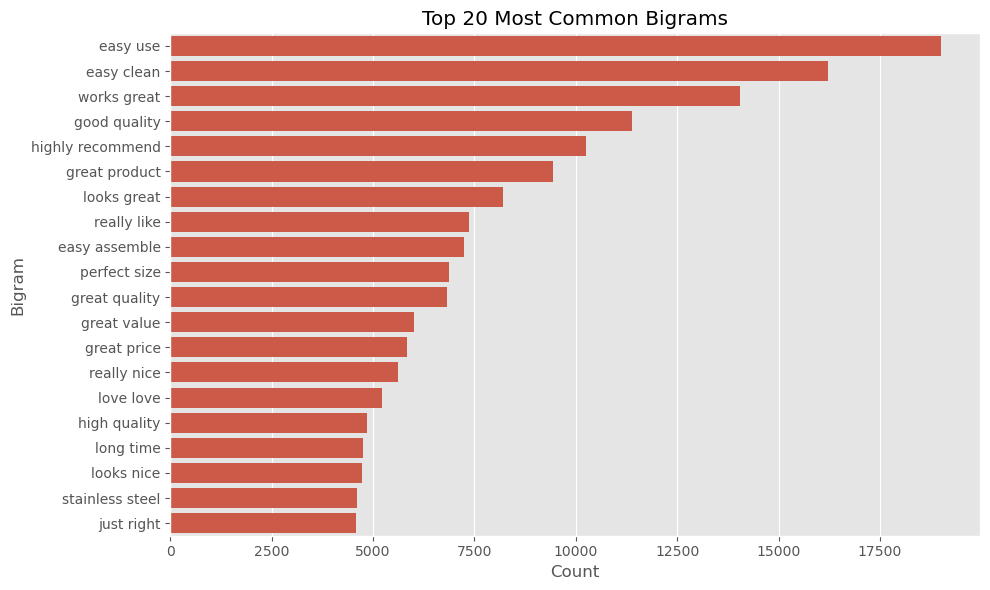

In [36]:
# Plot the top-20 frequent bigrams
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bigram_df.head(20),
    x="count",
    y="bigram"
)

plt.title("Top 20 Most Common Bigrams")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()


In [37]:
# Helper: frequent bigrams within a sentiment class
def get_top_bigrams_by_sentiment(sentiment, n=20):
    texts = reviews.loc[
        reviews["sentiment_label"] == sentiment,
        "clean_text"
    ]

    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        stop_words="english",
        max_features=5_000
    )

    matrix = vectorizer.fit_transform(texts)

    counts = matrix.sum(axis=0).A1

    return pd.DataFrame({
        "bigram": vectorizer.get_feature_names_out(),
        "count": counts
    }).sort_values(
        "count",
        ascending=False
    ).head(n)


In [38]:
negative_top_bigrams = get_top_bigrams_by_sentiment("negative", n=20)
negative_top_bigrams


,bigram,count
4646,waste money,2950
3089,poor quality,1545
1166,does work,1406
4000,stopped working,1259
2501,looks like,1003
973,did work,940
4941,worth money,836
2457,look like,615
820,customer service,615
3652,save money,602


In [39]:
neutral_top_bigrams = get_top_bigrams_by_sentiment("neutral", n=20)
neutral_top_bigrams


,bigram,count
1200,easy use,510
2629,looks like,497
1179,easy clean,479
2632,looks nice,448
2117,just ok,444
1084,does work,426
1611,good quality,422
1351,feel like,390
1037,does job,386
4006,smaller expected,375


In [40]:
positive_top_bigrams = get_top_bigrams_by_sentiment("positive", n=20)
positive_top_bigrams


,bigram,count
1177,easy use,18174
1117,easy clean,15448
4945,works great,13560
1590,good quality,10569
1976,highly recommend,10121
1790,great product,9199
2584,looks great,7847
3701,really like,6795
3265,perfect size,6721
1110,easy assemble,6694


In [41]:
reviews.groupby(
    "sentiment_label"
)["helpful_vote"].mean()

sentiment_label
negative    1.379225
neutral     0.999508
positive    0.846991
Name: helpful_vote, dtype: float64

In [42]:
pd.crosstab(
    reviews["verified_purchase"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

sentiment_label,negative,neutral,positive
verified_purchase,,,
False,6.499564,6.711005,86.789431
True,12.174222,7.131377,80.694401


In [43]:
# Create a year-month column for time analysis
reviews["year_month"] = (
    reviews["timestamp"]
    .dt.to_period("M")
    .astype(str)
)

reviews[["timestamp", "year_month"]].head()

,timestamp,year_month
0,2019-06-26 13:05:49.656,2019-06
1,2022-11-20 19:27:06.340,2022-11
2,2021-01-26 01:29:41.556,2021-01
3,2019-06-19 14:22:12.796,2019-06
4,2021-05-25 16:52:44.217,2021-05


In [44]:
# Count reviews per month
reviews_per_month = reviews.groupby(
    "year_month"
).size()

reviews_per_month.head()

year_month
2019-01    8276
2019-02    5996
2019-03    7050
2019-04    6262
2019-05    6743
dtype: int64

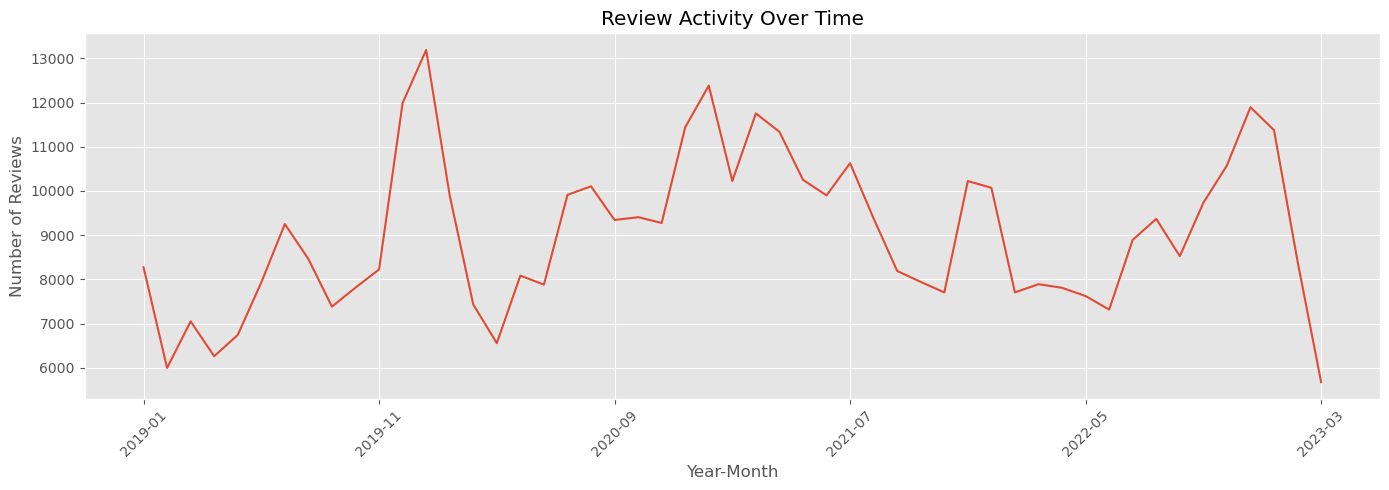

In [45]:
# Plot review activity over time
plt.figure(figsize=(14, 5))

reviews_per_month.plot()

plt.title("Review Activity Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# Sentiment class distribution per month
sentiment_over_time = pd.crosstab(
    reviews["year_month"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

sentiment_over_time.head()

sentiment_label,negative,neutral,positive
year_month,,,
2019-01,9.702755,6.222813,84.074432
2019-02,10.740494,6.187458,83.072048
2019-03,10.425532,6.921986,82.652482
2019-04,10.188438,6.898754,82.912807
2019-05,10.010381,6.525285,83.464333


<Figure size 1400x500 with 0 Axes>

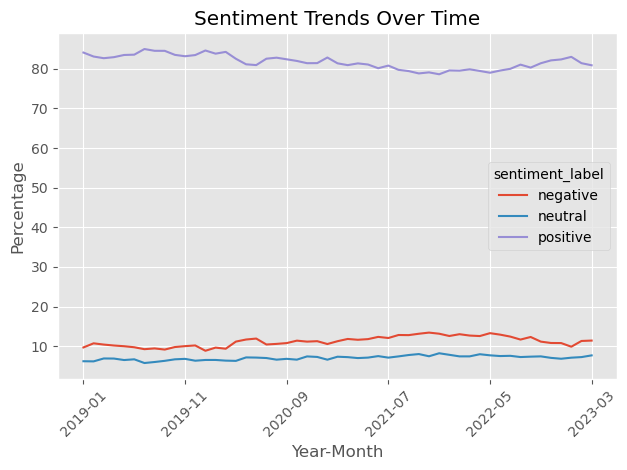

In [47]:
# Plot sentiment shares over time
plt.figure(figsize=(14, 5))

sentiment_over_time.plot()

plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### EDA findings

Key observations from the exploratory analysis:

- Strong class imbalance: about 82% of reviews are `positive`, while `neutral` and `negative` are much smaller.
- `Negative` reviews are on average longer and more detailed than `positive` ones.
- After stop-word removal, the most informative words relate to product quality, ease of use and user experience.
- Bigrams carry more context than single words (`works great`, `highly recommend`, `waste money`, `poor quality`) and separate the classes better.
- Word overlap between classes (`good`, `like`, `use`) means we need TF-IDF with unigrams and bigrams for modeling.
- `Negative` reviews receive more helpful votes on average — detailed problem descriptions are useful to other buyers.
- Verified buyers leave a higher share of negative reviews than non-verified users, although positive sentiment dominates in both groups.
- Review activity fluctuates by month; the share of positive reviews stays consistently dominant over the whole period.

Overall, the dataset reflects realistic user behavior and is well suited for building a production-style NLP pipeline.

Основные наблюдения разведочного анализа:

- Сильный дисбаланс классов: около 82% отзывов — `positive`, классов `neutral` и `negative` значительно меньше.
- `Negative`-отзывы в среднем длиннее и подробнее, чем `positive`.
- После удаления стоп-слов самые информативные слова касаются качества товара, удобства использования и пользовательского опыта.
- Биграммы дают больше контекста, чем отдельные слова (`works great`, `highly recommend`, `waste money`, `poor quality`), и лучше разделяют классы.
- Слова заметно пересекаются между классами (`good`, `like`, `use`), поэтому для моделей используем TF-IDF со словами и биграммами.
- `Negative`-отзывы в среднем получают больше голосов полезности — подробные описания проблем полезны другим покупателям.
- Подтверждённые покупатели оставляют большую долю негативных отзывов, чем неподтверждённые, хотя позитив доминирует в обеих группах.
- Активность отзывов колеблется по месяцам; доля позитивных отзывов стабильно доминирует на всём периоде.

В целом датасет отражает реалистичное поведение пользователей и хорошо подходит для построения NLP-пайплайна в продакшен-стиле.

## Saving the prepared dataset

We save the full dataset (including `clean_text`, `clean_text_no_stopwords`, `sentiment_label` and `year_month`) — notebooks 02 and 03 start by loading this file and do not repeat ingestion or cleaning.

Сохраняем полный датасет (включая `clean_text`, `clean_text_no_stopwords`, `sentiment_label` и `year_month`) — ноутбуки 02 и 03 начинают с загрузки этого файла и не повторяют загрузку и очистку данных.

In [48]:
# Save the prepared dataset for notebooks 02 and 03
reviews.to_parquet("data/reviews_clean.parquet")
print(f"Saved: data/reviews_clean.parquet, shape={reviews.shape}")

Saved: data/reviews_clean.parquet, shape=(460697, 14)
